# FSA Dimensionality Scaling: De Jong 1 vs. Rastrigin

How does Fast Simulated Annealing scale with dimensionality — and how does the **landscape** (unimodal vs. multimodal) change which parameters matter?

This notebook runs the same FSA configurations on two objective functions side by side:

| Function | Formula | Character |
|---|---|---|
| **De Jong 1** | $\sum x_i^2$ | unimodal, smooth bowl |
| **Rastrigin** | $An + \sum[x_i^2 - A\cos(2\pi x_i)]$ | multimodal, $\sim 10^n$ local traps |

Both share the domain $x_i \in [-5.12,\, 5.12]$ and global minimum $f^* = 0$ at the origin.

We test five configurations, each targeting a different aspect of the scaling problem:

| Config | $T_0$ | $n_0$ | $r$ | Primary change |
|---|---|---|---|---|
| `FSA_default` | $1$ | $100$ | $0.5$ | baseline |
| `FSA_r_scaled` | $1$ | $100$ | $0.5/\sqrt{n}$ | step norm |
| `FSA_tuned` | $1$ | $100n$ | $0.5/\sqrt{n}$ | + cooling horizon |
| `FSA_T0_tuned` | $10$ | $100n$ | $0.5/\sqrt{n}$ | + initial temperature |
| `FSA_precision_scaled` | $1$ | $100$ | $0.5\sqrt{\varepsilon/n}$ | step precision |

Note: `FSA_precision_scaled` uses the function's own success threshold $\varepsilon$ (`of.fstar`), so its $r$ differs between De Jong 1 ($\varepsilon=0.01$) and Rastrigin ($\varepsilon=0.5$).

In [1]:
# Import path to source directory (bit of a hack in Jupyter)
import sys
import os
pwd = %pwd
sys.path.append(os.path.join(pwd, '..', 'src'))

%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm

import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from heur_fsa import FastSimulatedAnnealing
from heur_aux import CauchyMutation, MirrorCorrection
from objfun_dejong1 import DeJong1
from objfun_rastrigin import Rastrigin

## Objective functions

In [3]:
for n in [2, 5, 10]:
    dj = DeJong1(n=n)
    ra = Rastrigin(n=n, eps=0.5)
    print(f'n={n:2d}  DeJong1: fstar={dj.fstar}   Rastrigin: fstar={ra.fstar}')

n= 2  DeJong1: fstar=0.01   Rastrigin: fstar=0.5
n= 5  DeJong1: fstar=0.01   Rastrigin: fstar=0.5
n=10  DeJong1: fstar=0.01   Rastrigin: fstar=0.5


## Experiment setup

In [4]:
def experiment(of, n, maxeval, num_runs, T0, n0, alpha, r, label):
    results = []
    for i in tqdm(range(num_runs), desc=f'{label}, n={n}'):
        mut = CauchyMutation(r=r, correction=MirrorCorrection(of))
        result = FastSimulatedAnnealing(
            of, maxeval=maxeval, T0=T0, n0=n0, alpha=alpha, mutation=mut, seed=i
        ).search()
        result.pop('log_data', None)
        result['run'] = i
        result['n'] = n
        result['heur'] = label
        results.append(result)
    return pd.DataFrame(results, columns=['heur', 'run', 'n', 'best_x', 'best_y', 'neval', 'success'])


def run_all(of_factory, dims, num_runs, maxeval_fn):
    """Run all configs × all dims for one objective function."""
    table = pd.DataFrame()
    for n in dims:
        of = of_factory(n)
        for label, params in get_configs(n, eps=of.fstar).items():
            res = experiment(of=of, n=n, maxeval=maxeval_fn(n), num_runs=num_runs, label=label, **params)
            table = pd.concat([table, res], ignore_index=True)
    return table


def compute_stats(table):
    def agg(g):
        rel = g['success'].mean()
        successful = g.loc[g['success'], 'neval']
        mne = successful.mean() if len(successful) > 0 else np.nan
        feo = mne / rel if (rel > 0 and not np.isnan(mne)) else np.nan
        return pd.Series({'rel': rel, 'mne': mne, 'feo': feo})
    return (
        table.groupby(['n', 'heur'])[['neval', 'success']]
        .apply(agg)
        .reset_index()
    )

## Parameters

In [5]:
DIMS     = [2, 5, 10]
NUM_RUNS = 500
ALPHA    = 2

def get_maxeval(n):
    return 2000 * n

def get_configs(n, eps):
    """Five configurations; precision_scaled uses the function's own success threshold."""
    return {
        'FSA_default':          dict(T0=1,  n0=100,     alpha=ALPHA, r=0.5),
        'FSA_r_scaled':         dict(T0=1,  n0=100,     alpha=ALPHA, r=0.5 / np.sqrt(n)),
        'FSA_tuned':            dict(T0=1,  n0=100 * n, alpha=ALPHA, r=0.5 / np.sqrt(n)),
        'FSA_T0_tuned':         dict(T0=10, n0=100 * n, alpha=ALPHA, r=0.5 / np.sqrt(n)),
        'FSA_precision_scaled': dict(T0=1,  n0=100,     alpha=ALPHA, r=0.5 * np.sqrt(eps / n)),
    }

HEUR_ORDER = ['FSA_default', 'FSA_r_scaled', 'FSA_tuned', 'FSA_T0_tuned', 'FSA_precision_scaled']
PALETTE    = sns.color_palette('muted', n_colors=len(HEUR_ORDER))
MARKERS    = ['o', 's', '^', 'D', 'v']
LINES      = ['-', '--', ':', '-.', '-']

print('Dimensions:', DIMS)
print('Budgets   :', [get_maxeval(n) for n in DIMS])
print('Runs each :', NUM_RUNS)

Dimensions: [2, 5, 10]
Budgets   : [4000, 10000, 20000]
Runs each : 500


## Run experiments

In [6]:
table_dj = run_all(
    of_factory=lambda n: DeJong1(n=n),
    dims=DIMS,
    num_runs=NUM_RUNS,
    maxeval_fn=get_maxeval,
)

FSA_default, n=2:   0%|          | 0/500 [00:00<?, ?it/s]

FSA_r_scaled, n=2:   0%|          | 0/500 [00:00<?, ?it/s]

FSA_tuned, n=2:   0%|          | 0/500 [00:00<?, ?it/s]

FSA_T0_tuned, n=2:   0%|          | 0/500 [00:00<?, ?it/s]

FSA_precision_scaled, n=2:   0%|          | 0/500 [00:00<?, ?it/s]

...

FSA_default, n=10:   0%|          | 0/500 [00:00<?, ?it/s]

FSA_r_scaled, n=10:   0%|          | 0/500 [00:00<?, ?it/s]

FSA_tuned, n=10:   0%|          | 0/500 [00:00<?, ?it/s]

FSA_T0_tuned, n=10:   0%|          | 0/500 [00:00<?, ?it/s]

FSA_precision_scaled, n=10:   0%|          | 0/500 [00:00<?, ?it/s]

In [7]:
table_ra = run_all(
    of_factory=lambda n: Rastrigin(n=n, eps=0.5),
    dims=DIMS,
    num_runs=NUM_RUNS,
    maxeval_fn=get_maxeval,
)

FSA_default, n=2:   0%|          | 0/500 [00:00<?, ?it/s]

FSA_r_scaled, n=2:   0%|          | 0/500 [00:00<?, ?it/s]

FSA_tuned, n=2:   0%|          | 0/500 [00:00<?, ?it/s]

FSA_T0_tuned, n=2:   0%|          | 0/500 [00:00<?, ?it/s]

FSA_precision_scaled, n=2:   0%|          | 0/500 [00:00<?, ?it/s]

...

FSA_default, n=10:   0%|          | 0/500 [00:00<?, ?it/s]

FSA_r_scaled, n=10:   0%|          | 0/500 [00:00<?, ?it/s]

FSA_tuned, n=10:   0%|          | 0/500 [00:00<?, ?it/s]

FSA_T0_tuned, n=10:   0%|          | 0/500 [00:00<?, ?it/s]

FSA_precision_scaled, n=10:   0%|          | 0/500 [00:00<?, ?it/s]

## Results

In [8]:
stats_dj = compute_stats(table_dj)
stats_ra = compute_stats(table_ra)

print('=== De Jong 1 ===')
print(stats_dj.to_string(index=False))
print()
print('=== Rastrigin ===')
print(stats_ra.to_string(index=False))

=== De Jong 1 ===
 n                 heur   rel         mne           feo
 2         FSA_T0_tuned 1.000  471.986000    471.986000
 2          FSA_default 1.000  196.860000    196.860000
 2 FSA_precision_scaled 1.000  215.636000    215.636000
 2         FSA_r_scaled 1.000  172.556000    172.556000
 2            FSA_tuned 1.000  201.138000    201.138000
 5         FSA_T0_tuned 0.194 7814.659794  40281.751515
 5          FSA_default 0.026 5136.923077 197573.964497
 5 FSA_precision_scaled 1.000  704.506000    704.506000
 5         FSA_r_scaled 0.806 4779.588089   5930.010036
 5            FSA_tuned 0.544 5976.805147  10986.774167
10         FSA_T0_tuned 0.000         NaN           NaN
10          FSA_default 0.000         NaN           NaN
10 FSA_precision_scaled 1.000 1820.556000   1820.556000
10         FSA_r_scaled 0.000         NaN           NaN
10            FSA_tuned 0.000         NaN           NaN

=== Rastrigin ===
 n                 heur   rel         mne          feo
 2         F

### Reliability

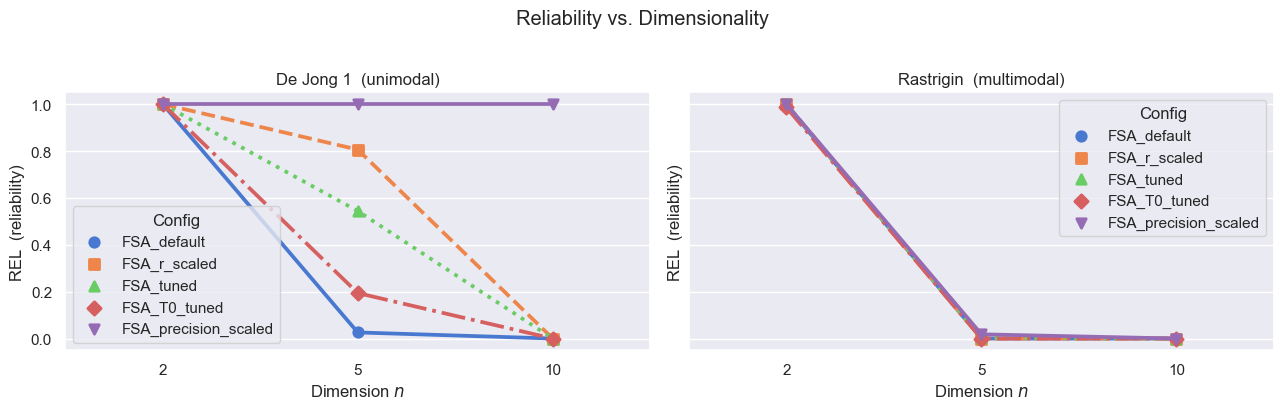

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

for ax, stats, title in zip(axes, [stats_dj, stats_ra], ['De Jong 1  (unimodal)', 'Rastrigin  (multimodal)']):
    sns.pointplot(
        data=stats, x='n', y='rel', hue='heur',
        hue_order=HEUR_ORDER, palette=PALETTE,
        markers=MARKERS, linestyles=LINES, ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel('Dimension $n$')
    ax.set_ylabel('REL  (reliability)')
    ax.legend(title='Config')

plt.suptitle('Reliability vs. Dimensionality', y=1.02)
plt.tight_layout()

### Mean Number of Evaluations

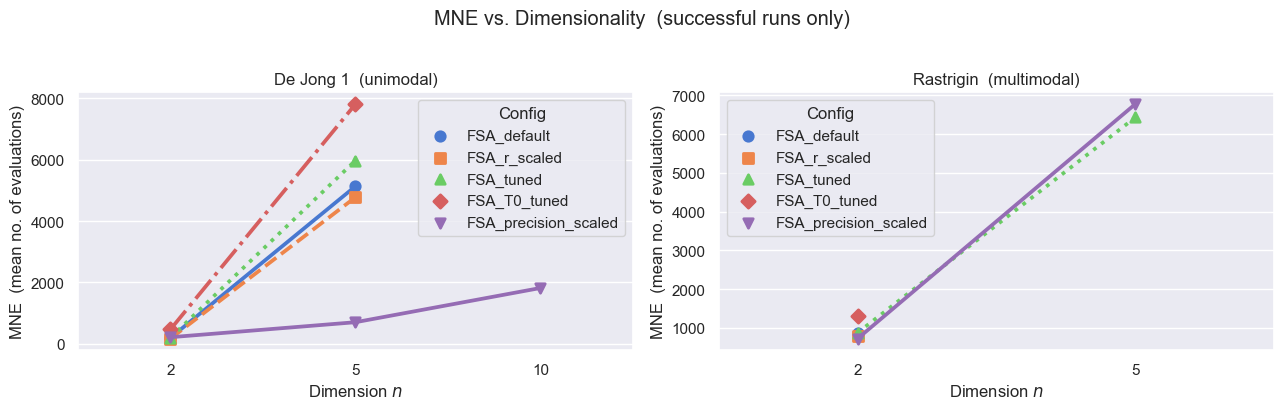

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, stats, title in zip(axes, [stats_dj, stats_ra], ['De Jong 1  (unimodal)', 'Rastrigin  (multimodal)']):
    sns.pointplot(
        data=stats.dropna(subset=['mne']), x='n', y='mne', hue='heur',
        hue_order=HEUR_ORDER, palette=PALETTE,
        markers=MARKERS, linestyles=LINES, ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel('Dimension $n$')
    ax.set_ylabel('MNE  (mean no. of evaluations)')
    ax.legend(title='Config')

plt.suptitle('MNE vs. Dimensionality  (successful runs only)', y=1.02)
plt.tight_layout()

### Feoktistov Criterion

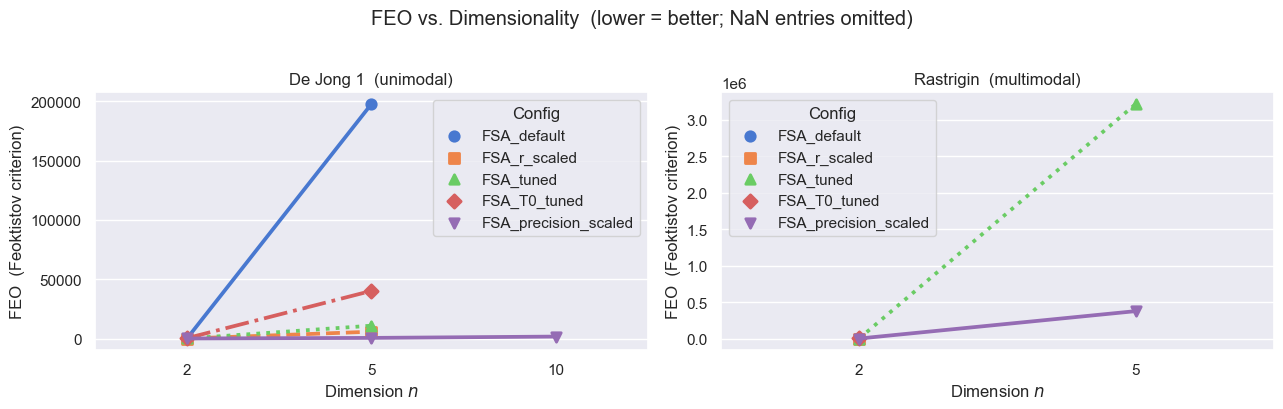

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, stats, title in zip(axes, [stats_dj, stats_ra], ['De Jong 1  (unimodal)', 'Rastrigin  (multimodal)']):
    sns.pointplot(
        data=stats.dropna(subset=['feo']), x='n', y='feo', hue='heur',
        hue_order=HEUR_ORDER, palette=PALETTE,
        markers=MARKERS, linestyles=LINES, ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel('Dimension $n$')
    ax.set_ylabel('FEO  (Feoktistov criterion)')
    ax.legend(title='Config')

plt.suptitle('FEO vs. Dimensionality  (lower = better; NaN entries omitted)', y=1.02)
plt.tight_layout()

### Summary tables

In [12]:
def pivot_stats(stats):
    p = stats.pivot_table(index='n', columns='heur', values=['rel', 'mne', 'feo'])
    p.columns = [f'{m}_{c}' for m, c in p.columns]
    return p.round(3)

print('=== De Jong 1 ===')
display(pivot_stats(stats_dj))
print('=== Rastrigin ===')
display(pivot_stats(stats_ra))

=== De Jong 1 ===


,feo_FSA_T0_tuned,feo_FSA_default,feo_FSA_precision_scaled,feo_FSA_r_scaled,feo_FSA_tuned,mne_FSA_T0_tuned,mne_FSA_default,mne_FSA_precision_scaled,mne_FSA_r_scaled,mne_FSA_tuned,rel_FSA_T0_tuned,rel_FSA_default,rel_FSA_precision_scaled,rel_FSA_r_scaled,rel_FSA_tuned
n,,,,,,,,,,,,,,,
2,471.986,196.860,215.636,172.556,201.138,471.986,196.860,215.636,172.556,201.138,1.000,1.000,1.0,1.000,1.000
5,40281.752,197573.964,704.506,5930.010,10986.774,7814.660,5136.923,704.506,4779.588,5976.805,0.194,0.026,1.0,0.806,0.544
10,NaN,NaN,1820.556,NaN,NaN,NaN,NaN,1820.556,NaN,NaN,0.000,0.000,1.0,0.000,0.000


=== Rastrigin ===


,feo_FSA_T0_tuned,feo_FSA_default,feo_FSA_precision_scaled,feo_FSA_r_scaled,feo_FSA_tuned,mne_FSA_T0_tuned,mne_FSA_default,mne_FSA_precision_scaled,mne_FSA_r_scaled,mne_FSA_tuned,rel_FSA_T0_tuned,rel_FSA_default,rel_FSA_precision_scaled,rel_FSA_r_scaled,rel_FSA_tuned
n,,,,,,,,,,,,,,,
2,1319.88,886.488,727.916,787.392,880.224,1301.402,882.942,727.916,787.392,880.224,0.986,0.996,1.000,1.0,1.000
5,NaN,NaN,376259.259,NaN,3214000.000,NaN,NaN,6772.667,NaN,6428.000,0.000,0.000,0.018,0.0,0.002
10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,0.000,0.000,0.0,0.000


## Conclusion

### De Jong 1 (unimodal)

At $n=2$ all five configurations reach REL = 1.0 — the smooth bowl is easy regardless of parametrisation.
Differences appear only in efficiency: `FSA_r_scaled` needs the fewest evaluations (FEO ≈ 173).

By $n=5$ the configurations diverge sharply.
`FSA_precision_scaled` (step size $r = 0.5\sqrt{\varepsilon/n}$) is the only one that stays at REL = 1.0 (FEO ≈ 705); every other variant loses reliability, with `FSA_default` dropping to REL = 0.026.

At $n=10$ the divergence is complete: `FSA_precision_scaled` is the **sole survivor** (REL = 1.0, FEO ≈ 1821).
All remaining configurations achieve REL = 0.

**Key take-away:** for unimodal landscapes, step-size scaling to the target precision ($r \propto \sqrt{\varepsilon/n}$) is the critical tuning knob; it keeps the step neither too coarse (overshoots the target region) nor too fine (explores too slowly).

### Rastrigin (multimodal)

At $n=2$ FSA handles the landscape adequately: most configurations reach REL ≥ 0.986, with `FSA_precision_scaled` and `FSA_r_scaled` at REL = 1.0.

The situation collapses at $n=5$. The best configuration (`FSA_precision_scaled`) achieves REL = 0.018 — 18 successes out of 1 000 runs. Every other variant rounds to 0.

At $n=10$ the collapse is total: **every configuration fails 100 % of the time.**

**Key take-away:** FSA's acceptance probability (temperature-based) is insufficient to systematically escape the exponentially growing grid of local minima that Rastrigin creates as $n$ increases.
A single-solution trajectory, no matter how well cooled, cannot explore enough of the landscape before the budget runs out.
This motivates switching to a **population-based** approach — as explored in the next notebook.